In [4]:
# 09/03
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, random_split, Subset, DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


적용된 폰트: ['Malgun Gothic']


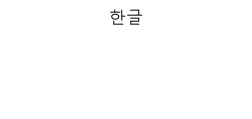

In [6]:
import platform
from matplotlib import font_manager

system = platform.system()
if system == 'Windows':
    # Windows는 맑은 고딕이 기본 내장되어 있어 설치 없이 바로 사용 가능
    plt.rc('font', family='Malgun Gothic')
elif system == 'Darwin':
    # macOS 기본 내장 한글 폰트
    plt.rc('font', family='AppleGothic')
else:
    # Colab 등 Linux: 위 셀에서 설치한 나눔고딕을 등록
    font_dir = '/usr/share/fonts/truetype/nanum'
    font_files = font_manager.findSystemFonts(fontpaths=font_dir)
    for fpath in font_files:
        font_manager.fontManager.addfont(fpath)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

# 설정한 폰트가 실제로 잡혔는지 확인
print('적용된 폰트:', plt.rcParams['font.family'])
plt.figure(figsize=(3,1))
plt.title('한글')
plt.axis('off')
plt.show()

In [7]:
base_dir = './data/chest_xray/'
if not os.path.isdir(base_dir):
    print('데이터 없음')
else:
    for split in ['train', 'test']:
        for cls in ['NORMAL', 'PNEUMONIA']:
            p = os.path.join(base_dir, split, cls)
            print(f'{split}/{cls:10s}: {len(os.listdir(p)):5d}장')

train/NORMAL    :  1341장
train/PNEUMONIA :  3875장
test/NORMAL    :   242장
test/PNEUMONIA :   398장


In [8]:
batch_size = 32
image_size = 224
learning_rate = 5e-4
epochs = 2
class_labels = ['NORMAL', 'PNEUMONIA']

In [9]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

train_tf = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomAffine(degrees=0,
                            translate=(0.1, 0.1),
                            scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

eval_tf = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

In [10]:
train_full = datasets.ImageFolder(os.path.join(base_dir, 'train'),
                                  transform = train_tf)
val_full = datasets.ImageFolder(os.path.join(base_dir, 'train'),
                                  transform = eval_tf)
test_full = datasets.ImageFolder(os.path.join(base_dir, 'test'),
                                  transform = eval_tf)

print(train_full.class_to_idx)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [11]:
n_total = len(train_full)
n_val = int(n_total * 0.2)
g = torch.Generator().manual_seed(42)
perm = torch.randperm(n_total, generator=g).tolist()
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_set = Subset(train_full, train_idx)
val_set = Subset(val_full, val_idx)
test_set = test_full

train_loader = DataLoader(train_set,
                          batch_size=batch_size,
                          shuffle=True)
val_loader = DataLoader(val_set,
                        batch_size=batch_size,
                        shuffle=False)
test_loader = DataLoader(test_set,
                        batch_size=batch_size,
                        shuffle=False)

print(len(train_set), len(val_set), len(test_set))

4173 1043 640


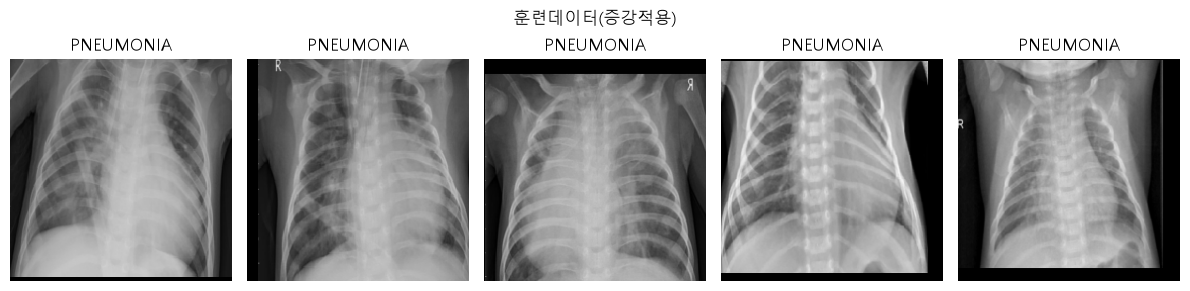

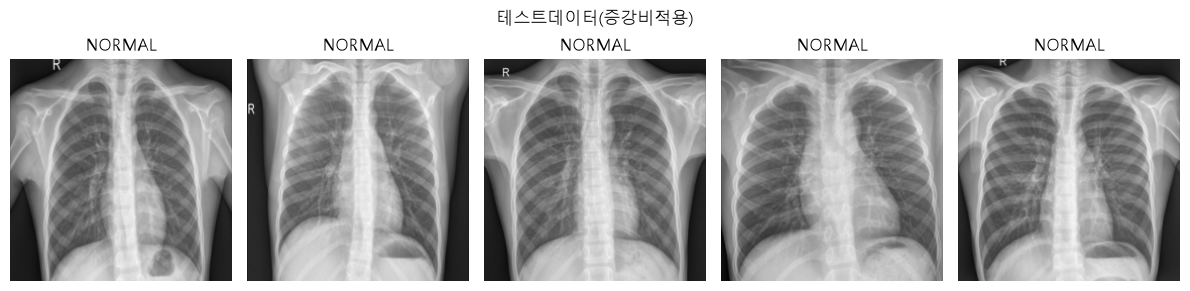

In [12]:
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t.cpu() * std + mean).clamp(0,1)

def show_images(loader, num_images=5, title=''):
    images, labels = next(iter(loader))
    plt.figure(figsize=(12,3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(denormalize(images[i]).permute(1,2,0).numpy())
        plt.title(class_labels[int(labels[i])])
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_images(train_loader, title='훈련데이터(증강적용)')
show_images(test_loader, title='테스트데이터(증강비적용)')

In [13]:
import timm

class XrayNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('resnetv2_50',
                                          pretrained=pretrained,
                                          num_classes=0,
                                          global_pool='avg')
        n_feat = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Linear(n_feat, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(128,1))

    def forward(self, x):
        return self.head(self.backbone(x))

model = XrayNet(pretrained=True)
with torch.no_grad():
    out = model(torch.zeros(2, 3,
                            image_size,
                            image_size))
print(f'출력 모양 {tuple(out.shape)}')
print(f'파라미터 {sum(p.numel() for p in model.parameters()):,}')

출력 모양 (2, 1)
파라미터 23,762,753


In [14]:
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             roc_auc_score, confusion_matrix)

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    losses, probs, trues = [], [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device).float()
        logits = model(xb).squeeze(1)

        if criterion is not None:
            losses.append(criterion(logits, yb).item() * len(yb))

        probs.append(torch.sigmoid(logits).cpu().numpy())
        trues.append(yb.cpu().numpy())

    probs = np.concatenate(probs)
    trues = np.concatenate(trues)
    preds = (probs > 0.5).astype(int)

    return {
        'loss': ((sum(losses)) / (len(trues))) if criterion is not None else None,
        'accuracy': accuracy_score(trues, preds),
        'recall': recall_score(trues, preds, zero_division=0),
        'precision': precision_score(trues, preds, zero_division=0),
        'auc': roc_auc_score(trues, probs) if len(set(trues)) > 1 else float('nan'),
        'probs': probs,
        'trues': trues,
        'preds': preds}

def train_model(model, train_loader,
                val_loader, epochs=20, lr=1e-3,
                ckpt_path='best_model2.pt',label='model'):
    model = model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,
        patience=2,
        min_lr=1e-7)

    history = {k: [] for k in ['loss', 'val_loss', 'accuracy', 'val_accuracy',
                               'val_recall', 'val_precision', 'val_auc']}
    best_val = float("inf")

    for epoch in range(1, epochs+1):
        model.train()
        run_loss, run_correct, n = 0.0, 0, 0
        t0 = time.time()

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device).float()
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * len(yb)
            run_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
            n += len(yb)

        tr_loss, tr_acc = run_loss / n, run_correct / n

        m = evaluate(model, val_loader, criterion)
        scheduler.step(m['loss'])

        history['loss'].append(tr_loss)
        history['accuracy'].append(tr_acc)
        history['val_loss'].append(m['loss'])
        history['val_accuracy'].append(m['accuracy'])
        history['val_recall'].append(m['recall'])
        history['val_precision'].append(m['precision'])
        history['val_auc'].append(m['auc'])

        star = ''
        if m['loss'] < best_val:
            best_val = m['loss']
            torch.save(model.state_dict(), ckpt_path)
            star = '저장'

        print(f'[{label}] {epoch:2d} / {epochs} '
              f'loss {tr_loss:4f} val_loss {m['loss']:4f} '
              f'val_acc {m['accuracy']:4f} val_auc {m['auc']:4f} '
              f'lr {optimizer.param_groups[0]['lr']:.1e} '
              f'{time.time()-t0:4f} {star}')
    print(f'best val_loss = {best_val:4f} {ckpt_path}')
    return history

In [16]:
model = XrayNet(pretrained = True)
history = train_model(model, train_loader, val_loader, epochs = epochs, lr = learning_rate)

[model]  1 / 2 loss 0.274852 val_loss 0.146643 val_acc 0.941515 val_auc 0.989160 lr 5.0e-04 80.762604 저장
[model]  2 / 2 loss 0.116650 val_loss 0.095060 val_acc 0.967402 val_auc 0.992872 lr 5.0e-04 75.527421 저장
best val_loss = 0.095060 best_model2.pt


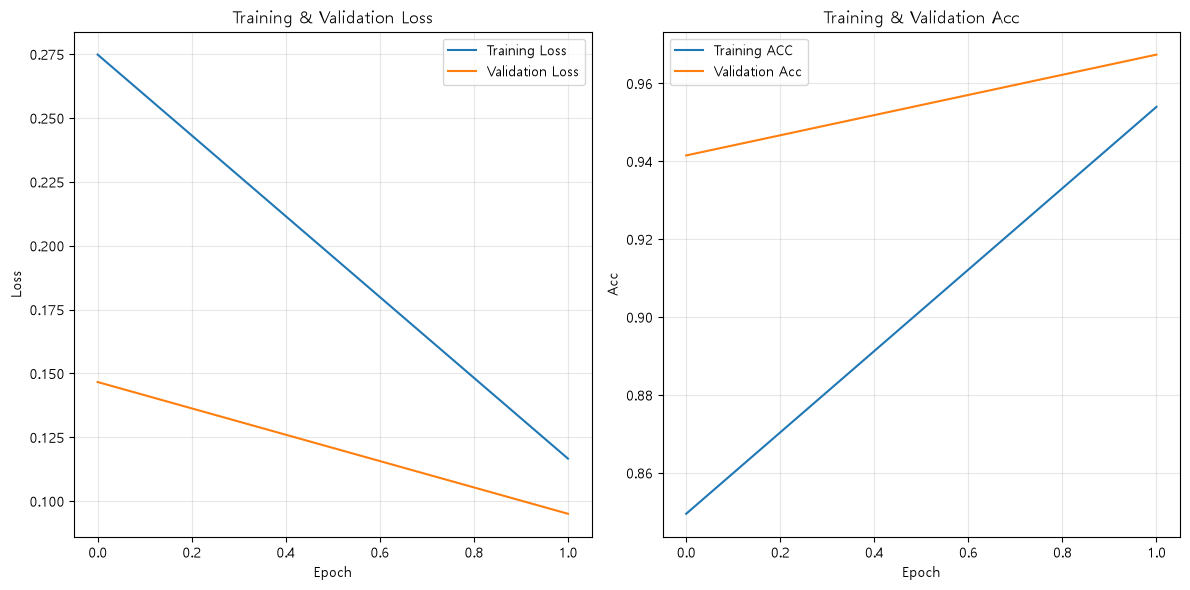

In [17]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history['accuracy'], label='Training ACC')
plt.plot(history['val_accuracy'], label='Validation Acc')
plt.title('Training & Validation Acc')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
best = XrayNet(pretrained=False).to(device)
best.load_state_dict(torch.load('best_model2.pt',
                                map_location=device))

m = evaluate(best, test_loader)

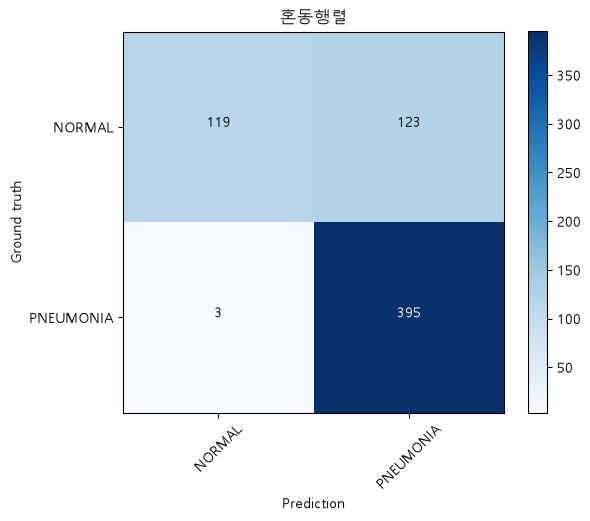

In [19]:
import itertools
import seaborn as sns


def plot_confusion(cm, classes, normalize=False, title='혼동행렬',
                   cmap=plt.cm.Blues):
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=45)
    plt.yticks(ticks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('Ground truth')
    plt.xlabel('Prediction')

cm = confusion_matrix(m['trues'], m['preds'])
plt.figure(figsize=(6,5))
plot_confusion(cm, classes=class_labels, title='혼동행렬')
plt.show()

In [ ]:
# 09/04
from sklearn.metrics import classification_report

print(classification_report(m['trues'], m['preds'],
                            target_names=class_labels))

              precision    recall  f1-score   support

      NORMAL       0.98      0.49      0.65       242
   PNEUMONIA       0.76      0.99      0.86       398

    accuracy                           0.80       640
   macro avg       0.87      0.74      0.76       640
weighted avg       0.84      0.80      0.78       640



In [32]:
from sklearn.metrics import (balanced_accuracy_score,
                             average_precision_score)

def medical_metrics(trues, preds, probs):
    tn, fp, fn, tp = confusion_matrix(trues, preds).ravel()

    return {
        '정확도': (tp + tn) / (tp + tn + fp + fn),
        '균형 정확도': balanced_accuracy_score(trues, preds),
        '민감도': tp / (tp + fn) if (tp + fn) else 0.0,
        '특이도': tn / (tn + fp) if (tn + fp) else 0.0,
        '정밀도': tp / (tp + fp) if (tp + fp) else 0.0,
        'NPV': tn / (tn + fn) if (tn + fn) else 0.0,
        'ROC_AUC': roc_auc_score(trues, preds),
        'PR_AUC': average_precision_score(trues, preds),
        '_counts': (tn, fp, fn, tp)}

res = medical_metrics(m['trues'], m['preds'], m['probs'])
tn, fp, fn, tp = res.pop('_counts')

n_norm = int((m['trues'] == 0).sum())
n_pneu = int((m['trues'] == 1).sum())

print(f'정상: {n_norm}, 폐렴: {n_pneu}')
print(f'{n_pneu / (n_norm + n_pneu):.1%}')

for k, v in res.items():
    mark = ' 중요' if k == '민감도' else ''
    print(f'{k:12s} : {v:.4f}{mark}')

print(f'놓친 폐렴 환자(FN): {fn}명')
print(f'정상 -> 폐렴으로 오진(FP): {fp}명')

정상: 242, 폐렴: 398
62.2%
정확도          : 0.8031
균형 정확도       : 0.7421
민감도          : 0.9925 중요
특이도          : 0.4917
정밀도          : 0.7625
NPV          : 0.9754
ROC_AUC      : 0.7421
PR_AUC       : 0.7615
놓친 폐렴 환자(FN): 3명
정상 -> 폐렴으로 오진(FP): 123명


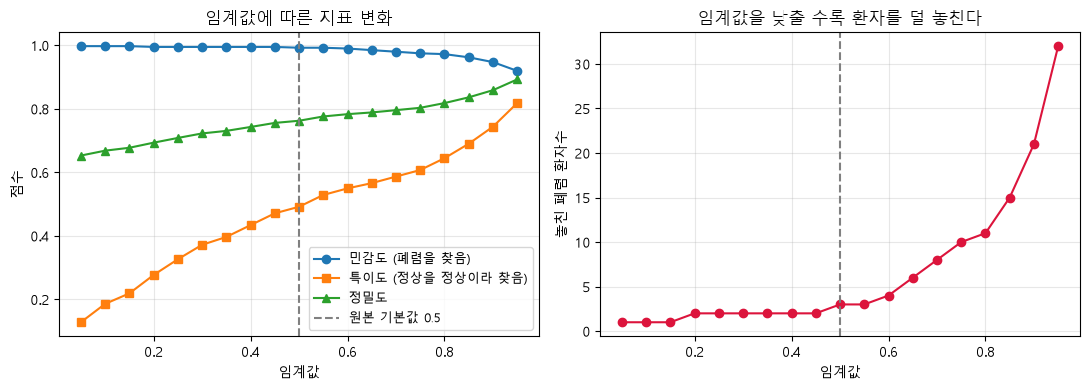

민감도 99% 이상을 만족하는 임계값 중 특이도가 제일 높은 지점
임계값 0.55 -> 민감도 0.9925 특이값 0.5289 놓친 환자 3


In [39]:
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []
for t in thresholds:
    p = (m['probs'] > t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(m['trues'], p,
                                          labels=[0,1]).ravel()
    rows.append({
        'threshold': t,
        'sens': tp_ / (tp_ + fn_) if (tp_ + fn_) else 0.0,
        'spec': tn_ / (tn_ + fp_) if (tn_ + fp_) else 0.0,
        'prec': tp_ / (tp_ + fp_) if (tp_ + fp_) else 0.0,
        'fn': fn_})

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(thresholds, [r['sens'] for r in rows], 'o-', label='민감도 (폐렴을 찾음)')
plt.plot(thresholds, [r['spec'] for r in rows], 's-', label='특이도 (정상을 정상이라 찾음)')
plt.plot(thresholds, [r['prec'] for r in rows], '^-', label='정밀도')
plt.axvline(0.5, color='gray', ls='--', label= '원본 기본값 0.5')
plt.xlabel('임계값')
plt.ylabel('점수')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.title('임계값에 따른 지표 변화')

plt.subplot(1,2,2)
plt.plot(thresholds, [r['fn'] for r in rows], 'o-', color='crimson')
plt.axvline(0.5, color='gray', ls='--')
plt.xlabel('임계값')
plt.ylabel('놓친 폐렴 환자수')
plt.title('임계값을 낮출 수록 환자를 덜 놓친다')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

TARGET = 0.99
candidates = [r for r in rows if r['sens'] >= TARGET]
if candidates:
    chosen = max(candidates, key=lambda r: r['spec'])
    print(f'민감도 {TARGET:.0%} 이상을 만족하는 임계값 중 특이도가 제일 높은 지점')
    print(f'임계값 {chosen['threshold']:.2f} -> 민감도 {chosen['sens']:.4f}'
          f' 특이값 {chosen['spec']:.4f} 놓친 환자 {chosen['fn']}')
else:
    print(f'민감도 {TARGET:.0%}를 만족하는 임계값이 없음. 추가 학습 필요')

In [46]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.acts = None
        self.grads = None
        self.handles = [
            target_layer.register_forward_hook(self._save_acts),
            target_layer.register_full_backward_hook(self._save_grads)]

    def _save_acts(self, module, inp, out):
        self.acts = out.detach()
    def _save_grads(self, module, grad_in, grad_out):
        self.grads = grad_out[0].detach()
    def __call__(self, x):
        self.model.zero_grad()
        logit = self.model(x).squeeze()
        logit.backward()

        weights = self.grads.mean(dim=(2,3),
                                  keepdim=True)
        heat = (weights*self.acts).sum(dim=1).squeeze(0)
        if heat.max() > 0:
            heat=heat / heat.max()
        return heat.cpu().numpy()
    def remove(self):
        for h in self.handles:
            h.remove()

def overlay_heatmap(heat, img01, alpha=0.4):
    import torch.nn.functional as F
    h = torch.from_numpy(heat) [None, None]
    h = F.interpolate(h, size=img01.shape[:2],
                      mode='bilinear',
                      align_corners=False)[0,0].numpy()
    jet = plt.get_cmap('jet')(h)[:,:,:3]
    return np.clip(img01 * (1-alpha) + jet * alpha, 0, 1)

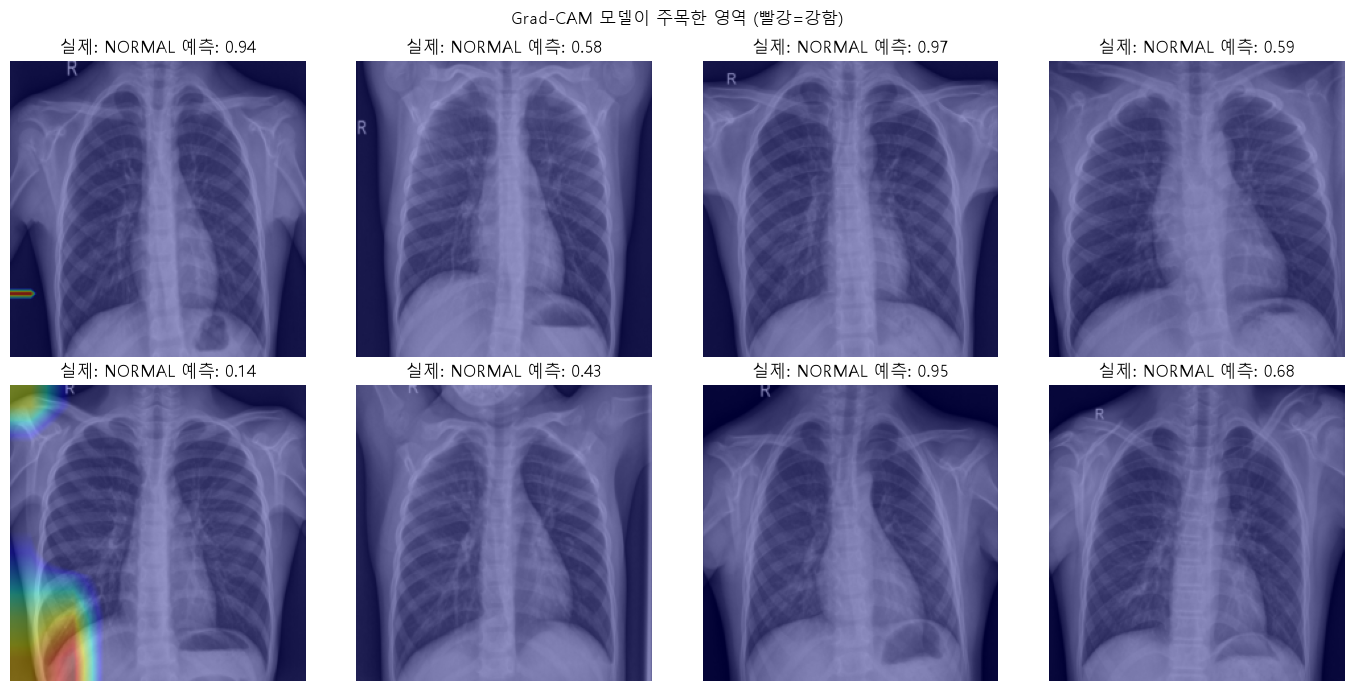

In [49]:
target_layer = best.backbone.stages[-1]
cam = GradCAM(best, target_layer)

fig, ax = plt.subplots(2, 4, figsize=(14,7))
it = iter(test_loader)
xb, yb = next(it)

for k in range(8):
    i, j = divmod(k, 4)
    x = xb[k:k+1].to(device)
    lab = int(yb[k])

    heat = cam(x)
    img01 = denormalize(xb[k]).permute(1,2,0).numpy()

    with torch.no_grad():
        p = torch.sigmoid(best(x)).item()

    ax[i, j].imshow(overlay_heatmap(heat, img01))
    ax[i, j].set_title(f'실제: {class_labels[lab]} 예측: {p:.2f}')
    ax[i, j].axis('off')

cam.remove()
plt.suptitle('Grad-CAM 모델이 주목한 영역 (빨강=강함)')
plt.tight_layout()
plt.show()